In [1]:
from gbm.binning.unbinned import bin_by_time
import os
from gbm.plot import Lightcurve

view_range = (-10.0, 100.0)
bkgd_range = [(-20., -5.), (45., 100.)]
src_range = (10.0, 13.0)
erange_nai = (8.0, 900.0)
erange_bgo = (325., 25000.)

In [2]:
from gbm.data import Cspec, GbmDetectorCollection

test_pha_n7 = os.path.join('..', 'data', 'glg_cspec_n7_bn090926181_v00.pha')
test_pha_n3 = os.path.join('..', 'data', 'glg_cspec_n3_bn090926181_v00.pha')
test_pha_b0 = os.path.join('..', 'data', 'glg_cspec_b0_bn090926181_v00.pha')
n7 = Cspec.open(test_pha_n7)
n3 = Cspec.open(test_pha_n3)
b0 = Cspec.open(test_pha_b0)

cspecs = GbmDetectorCollection.from_list([n7, n3, b0])

In [3]:
from gbm.background import BackgroundFitter
from gbm.background.binned import Polynomial

backfitters = [BackgroundFitter.from_phaii(cspec, Polynomial, time_ranges=bkgd_range) for cspec in cspecs]
backfitters = GbmDetectorCollection.from_list(backfitters, dets=cspecs.detector())

# do the fit
backfitters.fit(order=1)

# interpolate/extrapolate and store in a collection
bkgds = backfitters.interpolate_bins(cspecs.data()[0].tstart, cspecs.data()[0].tstop)
bkgds = GbmDetectorCollection.from_list(bkgds, dets=cspecs.detector())

In [4]:
# the lightcurves
data_lcs = cspecs.to_lightcurve(nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})
# the energy-integrated background
bkgd_lcs = bkgds.integrate_energy(nai_args=erange_nai, bgo_args=erange_bgo)
# the source time selection
src_lcs = cspecs.to_lightcurve(time_range=src_range, nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})

# the count spectrum
data_specs = cspecs.to_spectrum(time_range=src_range)
# the time-integrated background
bkgd_specs = bkgds.integrate_time(*src_range)
# the energy selection
src_specs = cspecs.to_spectrum(time_range=src_range, nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})

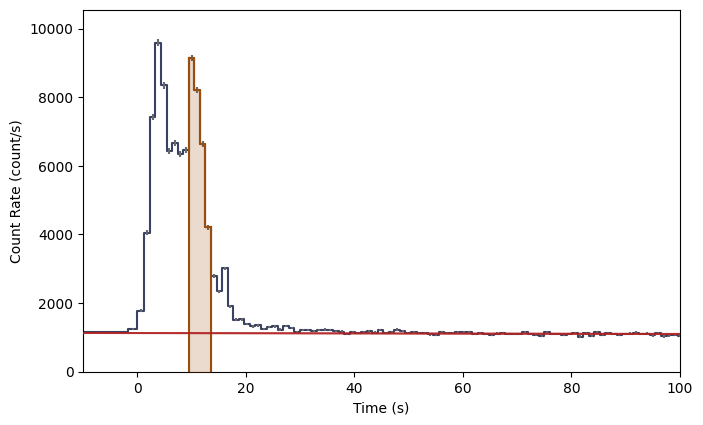

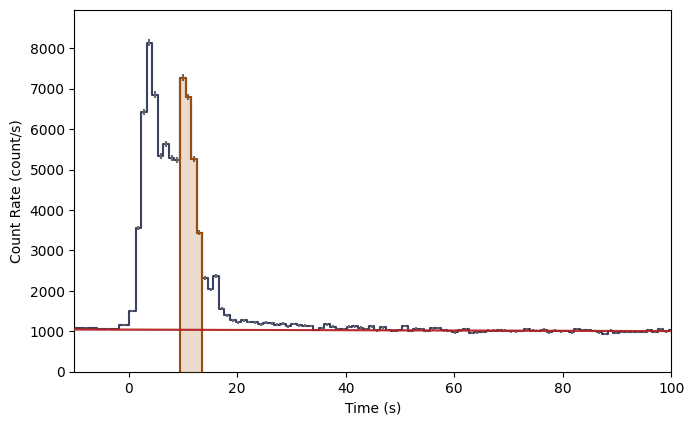

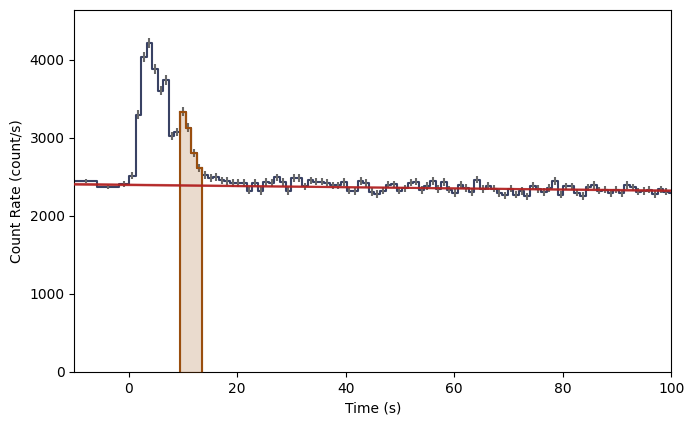

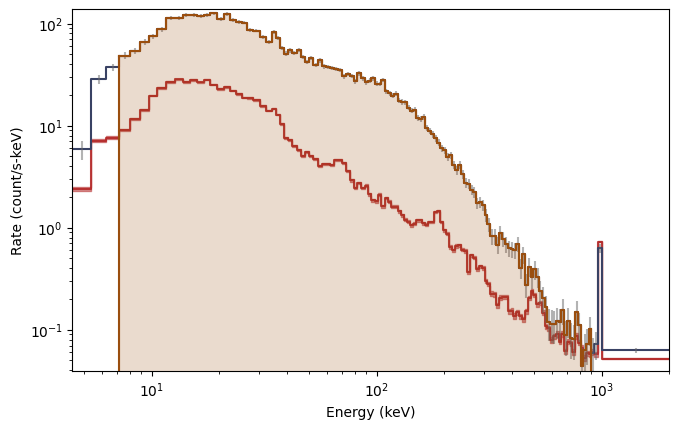

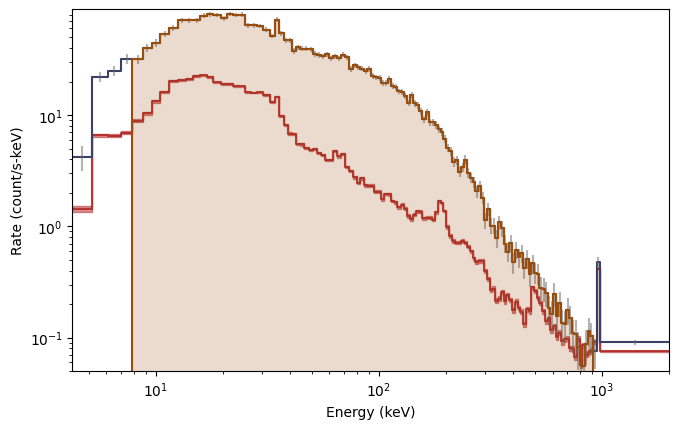

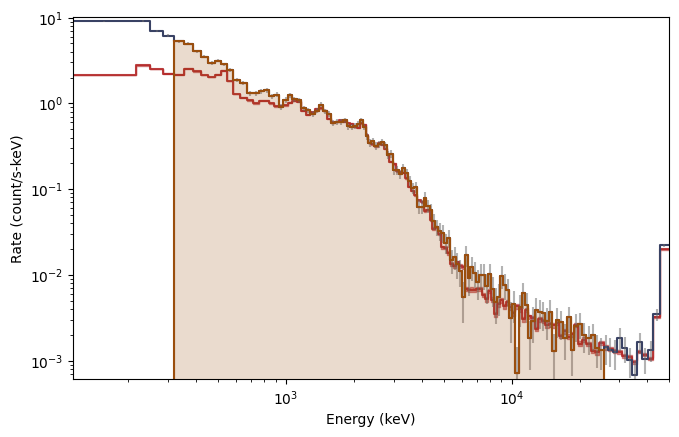

In [5]:
%matplotlib inline
from gbm.plot import Lightcurve, Spectrum

# Plot the lightcurves with the selections and background fit
lcplots = [Lightcurve(data=data_lc, background=bkgd_lc) for data_lc, bkgd_lc in zip(data_lcs, bkgd_lcs)]
_ = [lcplot.add_selection(src_lc) for lcplot, src_lc in zip(lcplots, src_lcs)]
# zoom in
for lcplot in lcplots:
    lcplot.xlim = view_range

# Plot the spectra with the selections and background fit
specplots = [Spectrum(data=data_spec, background=bkgd_spec) for data_spec, bkgd_spec in zip(data_specs, bkgd_specs)]
_ = [specplot.add_selection(src_spec) for specplot, src_spec in zip(specplots, src_specs)]

In [12]:
from gbm.spectra.fitting import SpectralFitterCstat
from gbm.data import RSP
from gbm.spectra.functions import PowerLaw, Comptonized, Band, BlackBody
import numpy as np

phas = cspecs.to_pha(time_ranges=src_range, nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})

rsp_dir_n7 = os.path.join('..', 'data', 'glg_cspec_n7_bn090926181_v00.rsp2')
rsp_dir_n3 = os.path.join('..', 'data', 'glg_cspec_n3_bn090926181_v00.rsp2')
rsp_dir_b0 = os.path.join('..', 'data', 'glg_cspec_b0_bn090926181_v00.rsp2')

# open responses
rsp1 = RSP.open(rsp_dir_n7)
rsp2 = RSP.open(rsp_dir_n3)
rsp3 = RSP.open(rsp_dir_b0)
rsps = GbmDetectorCollection.from_list([rsp1, rsp2, rsp3])

# and interpolate response files to get DRMs at center of the source window
rsps_interp = [rsp.interpolate(pha.tcent) for rsp, pha in zip(rsps, phas)]

# we initialize with our PHAs, backgrounds, and responses:
specfitter = SpectralFitterCstat(phas, bkgds.to_list(), rsps_interp, method='TNC')

blackbody = BlackBody()
specfitter.fit(blackbody, options={'maxiter': 1000})
print("BlackBody Fit:")
print(specfitter.message)
print('Parameters: {}'.format(specfitter.parameters))
print('90% Asymm. Errors:\n {}'.format(specfitter.asymmetric_errors(cl=0.9)))
print('Cstat/DoF: {}/{}'.format(specfitter.statistic, specfitter.dof))

bb_params = specfitter.parameters.copy()
bb_cov = specfitter.covariance.copy()

BlackBody Fit:
Max. number of function evaluations reached
Parameters: [6.15807808e-04 2.99879092e+01]
90% Asymm. Errors:
 [[8.67801786e-06 8.70363356e-06]
 [1.45302863e-01 1.09045691e-01]]
Cstat/DoF: 3100.530959484324/352


In [7]:
band = Band()
band.param_list

print('Band:')
print(band.default_values)
print(band.min_values)
print(band.max_values)

print('Band Fit:')
specfitter.fit(band, options={'maxiter': 1000})

# Extrae los parámetros del ajuste de Band
params_band = specfitter.parameters

# After the fit has converged, we can query the fitter for lots of info, including the parameters that
# satisfy the maximum likelihood as well as the parameter uncertainties resulting from -2(Delta)LogLike
print(specfitter.message)
print('Parameters: {}'.format(specfitter.parameters))
print('90% Asymm. Errors:\n {}'.format(specfitter.asymmetric_errors(cl=0.9)))
print('Cstat/DoF: {}/{}'.format(specfitter.statistic, specfitter.dof))

Band:
[0.01, 500.0, -0.5, -2.5, 100.0]
[1e-10, 0.01, -1.9, -10.0, 0.01]
[inf, inf, 20.0, -2.0001, inf]
Band Fit:


Max. number of function evaluations reached
Parameters: [ 2.41108224e-01  2.52556781e+02 -8.51917704e-01 -2.86071232e+00]
90% Asymm. Errors:
 [[3.78802819e-03 3.80549262e-03]
 [6.47662360e+00 6.62046120e+00]
 [1.69406554e-02 1.71939684e-02]
 [7.45994177e-01 3.07638080e-01]]
Cstat/DoF: 238.872522221814/350


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

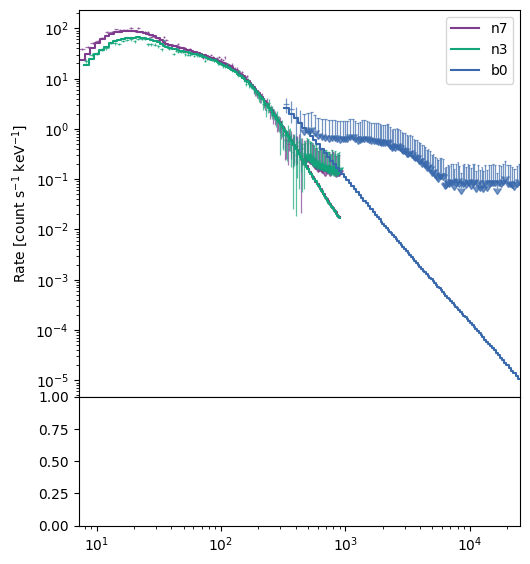

In [10]:
from gbm.plot import ModelFit
import numpy as np

if not hasattr(np, 'VisibleDeprecationWarning'):
    # Mapear a DeprecationWarning para compatibilidad con paquetes que lo esperan
    np.VisibleDeprecationWarning = DeprecationWarning

# initialize with your spectral fitter once the fit is done
modelplot = ModelFit(fitter=specfitter)

In [ ]:
# we've defined a new model that is the sum of a Comptonized function and a power law
comp_pl = Comptonized() + PowerLaw()

print(comp_pl.param_list)

# rerun the fit
print('Comp+PL Fit:')
specfitter.fit(comp_pl, options= {'maxiter': 1000})

params_comp_pl = specfitter.parameters

print(specfitter.message)
print('Parameters: {}'.format(specfitter.parameters))
print('90% Asymm. Errors:\n {}'.format(specfitter.asymmetric_errors(cl=0.9)))
print('Cstat/DoF: {}/{}'.format(specfitter.statistic, specfitter.dof))

[('Comptonized: A', 'ph/s/cm^2/keV', 'Amplitude'), ('Comptonized: Epeak', 'keV', 'SED Peak'), ('Comptonized: index', '', 'Photon index'), ('Comptonized: Epiv', 'keV', 'Pivot energy'), ('PowerLaw: A', 'ph/s/cm^2/keV', 'Amplitude'), ('PowerLaw: index', '', 'Photon index'), ('PowerLaw: Epiv', '', 'Pivot energy')]
Comp+PL Fit:
Max. number of function evaluations reached
Parameters: [ 2.58725012e-01  2.25221208e+02 -4.63324887e-01  2.50801757e-02
 -1.70855597e+00]
90% Asymm. Errors:
 [[5.85462446e-03 5.91363877e-03]
 [5.34468207e+00 5.41265874e+00]
 [2.85398311e-02 2.92266704e-02]
 [1.53228431e-03 1.55062738e-03]
 [4.30793839e-02 4.30793839e-02]]
Cstat/DoF: 221.8070858433319/349


/home/reegh/Documentos/Astro/Astro-GRBs/gbm/lib/python3.10/site-packages/gbm/spectra/fitting.py:600: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = multivariate_normal(self.parameters, self.covariance,


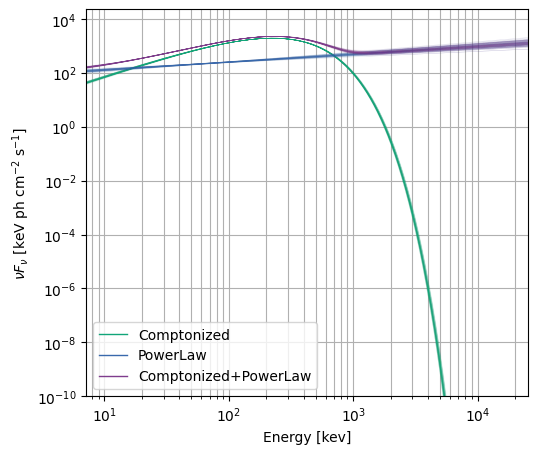

In [ ]:
modelplot = ModelFit(fitter=specfitter, view='nufnu')
modelplot.ax.grid(which='both')